# Guidance + binding affinity training (fixed)

This notebook bundles the corrected guidance wrapper with a minimal, working pipeline to train a binding-affinity predictor from TargetDiff sampling outputs (\*.pt) and a protein pocket PDB. It avoids the batching/centering bugs from the earlier version and uses real protein atomic numbers.

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, random_split
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.utils import scatter
from pathlib import Path
from rdkit import Chem
from tqdm.auto import tqdm
import utils.transforms as trans


/home/jzay/moment/predict_binding_affinity/datasets/protein_ligand.py:16: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"): np.object = object


In [2]:
# radius graph helper used by both dataset (optional) and model

def build_radius_edge_index(pos: torch.Tensor, batch: torch.Tensor = None, r: float = 5.0, loop: bool = False):
    """
    Pure PyTorch radius graph that respects batch.
    pos: [N, 3]
    batch: [N] or None
    returns edge_index: [2, E]
    """
    if batch is None:
        batch = torch.zeros(pos.size(0), dtype=torch.long, device=pos.device)

    edge_src = []
    edge_dst = []

    for b in batch.unique():
        mask = batch == b
        idx = mask.nonzero(as_tuple=True)[0]
        if idx.numel() == 0:
            continue
        sub_pos = pos[idx]

        dist = torch.cdist(sub_pos, sub_pos, p=2)
        sub_mask = dist <= r
        if not loop:
            sub_mask = sub_mask & ~torch.eye(len(idx), dtype=torch.bool, device=pos.device)

        src, dst = sub_mask.nonzero(as_tuple=True)
        edge_src.append(idx[src])
        edge_dst.append(idx[dst])

    if len(edge_src) == 0:
        return torch.empty(2, 0, dtype=torch.long, device=pos.device)
    edge_index = torch.stack([torch.cat(edge_src), torch.cat(edge_dst)], dim=0)
    return edge_index


In [3]:
# pocket + ligand helpers

AA_TYPES = [
    "ALA","ARG","ASN","ASP","CYS","GLN","GLU","GLY","HIS",
    "ILE","LEU","LYS","MET","PHE","PRO","SER","THR","TRP","TYR","VAL"
]
ELEM_TYPES = ["H","C","N","O","S","P","F","Cl","Br","I"]
PTABLE = Chem.GetPeriodicTable()


def load_pocket(pdb_path):
    coords, z_list, feats = [], [], []

    with open(pdb_path) as f:
        for line in f:
            if not line.startswith("ATOM"):
                continue
            x = float(line[30:38]); y = float(line[38:46]); z = float(line[46:54])
            res = line[17:20].strip()
            elem = line[76:78].strip() or line[12:16].strip()[0]
            atomic_num = PTABLE.GetAtomicNumber(elem)

            aa_oh = torch.zeros(len(AA_TYPES))
            if res in AA_TYPES:
                aa_oh[AA_TYPES.index(res)] = 1.0

            el_oh = torch.zeros(len(ELEM_TYPES))
            if elem in ELEM_TYPES:
                el_oh[ELEM_TYPES.index(elem)] = 1.0

            coords.append([x, y, z])
            z_list.append(atomic_num)
            feats.append(torch.cat([aa_oh, el_oh]))

    pocket_pos = torch.tensor(coords, dtype=torch.float32)
    pocket_z   = torch.tensor(z_list, dtype=torch.long)
    pocket_x   = torch.stack(feats, dim=0) if len(feats) > 0 else None
    return pocket_pos, pocket_z, pocket_x


def mol_to_ligand_tensors(mol, pred_pos):
    n_atoms = mol.GetNumAtoms()
    pos = torch.as_tensor(pred_pos, dtype=torch.float32)
    assert pos.shape[0] == n_atoms, f"pos has {pos.shape[0]} atoms, mol has {n_atoms}"
    z = torch.tensor([atom.GetAtomicNum() for atom in mol.GetAtoms()], dtype=torch.long)
    return pos, z


In [4]:
class LigandPocketFromPT(Dataset):
    """
    Dataset that builds ligand+pocket graphs from TargetDiff sampling outputs (saved .pt files).
    Each record is expected to have keys: mol, pred_pos, vina[vina_mode][0]['affinity']
    and optional chem_results (qed/sa/logp) and smiles.
    """
    def __init__(self, pt_path=None, pt_dir=None, pdb_path=None, vina_mode="score_only", max_affinity=None,
                 results_key="all_results", build_edges=False, edge_radius=6.0):
        assert pdb_path is not None, "pdb_path is required"
        assert (pt_path is not None) or (pt_dir is not None), "Provide pt_path or pt_dir"
        self.vina_mode = vina_mode
        self.build_edges = build_edges
        self.edge_radius = edge_radius

        results = []
        pt_files = []
        if pt_dir is not None:
            for p in sorted(Path(pt_dir).glob("*.pt")):
                obj = torch.load(p, map_location="cpu",  weights_only=False)
                if results_key in obj:
                    results.extend(obj[results_key])
                elif "results" in obj:
                    results.extend(obj["results"])
                pt_files.append(p)
        else:
            obj = torch.load(pt_path, map_location="cpu",  weights_only=False)
            if results_key in obj:
                results.extend(obj[results_key])
            elif "results" in obj:
                results.extend(obj["results"])
            pt_files.append(pt_path)

        self.results = results
        self.pt_files = pt_files
        self.pocket_pos, self.pocket_z, self.pocket_x = load_pocket(pdb_path)

        if max_affinity is None:
            self.indices = list(range(len(self.results)))
        else:
            self.indices = [
                i for i, r in enumerate(self.results)
                if r["vina"][self.vina_mode][0]["affinity"] <= max_affinity
            ]
            if len(self.indices) == 0:
                raise ValueError("All samples filtered out; relax max_affinity")

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        rec = self.results[self.indices[idx]]
        mol      = rec["mol"]
        pred_pos = rec["pred_pos"]
        vina_rec = rec["vina"][self.vina_mode][0]

        lig_pos, z_lig = mol_to_ligand_tensors(mol, pred_pos)

        pos = torch.cat([lig_pos, self.pocket_pos], dim=0)
        z   = torch.cat([z_lig, self.pocket_z], dim=0)
        node_type = torch.cat([
            torch.ones(lig_pos.size(0), dtype=torch.long),
            torch.zeros(self.pocket_pos.size(0), dtype=torch.long)
        ])

        y = torch.tensor([vina_rec["affinity"]], dtype=torch.float32)
        data = Data(
            pos=pos,
            z=z,
            y=y,
            node_type=node_type,
            smiles=rec.get("smiles"),
        )

        chem = rec.get("chem_results", {})
        if chem:
            for key in ("qed", "sa", "logp"):
                if key in chem:
                    data[key] = torch.tensor([chem[key]], dtype=torch.float32)

        if self.build_edges:
            data.edge_index = build_radius_edge_index(pos, batch=None, r=self.edge_radius)

        return data


## Build dataset + loaders

Edit the paths below to point at your pocket PDB and TargetDiff sampling outputs (.pt files).

In [5]:
# Paths to your data
PT_DIR   = "metrics_dir"          # directory of .pt files OR set PT_PATH instead
PT_PATH  = None                    # single .pt file
PDB_PATH = "y220c_pocket10.pdb"   # pocket used in sampling
VINA_MODE = "score_only"                 # one of: dock, minimize, score_only
MAX_AFFINITY = None                # e.g., 0.0 to clip outliers
BUILD_EDGES = False                # set True to precompute edges in dataset
EDGE_RADIUS = 6.0

# Build dataset
train_ratio = 0.8
val_ratio   = 0.1
batch_size  = 32

pt_kwargs = {"pt_dir": PT_DIR, "pt_path": PT_PATH}
pt_kwargs = {k: v for k, v in pt_kwargs.items() if v is not None}

ds = LigandPocketFromPT(
    pdb_path=PDB_PATH,
    vina_mode=VINA_MODE,
    max_affinity=MAX_AFFINITY,
    build_edges=BUILD_EDGES,
    edge_radius=EDGE_RADIUS,
    **pt_kwargs,
)
print(f"Loaded {len(ds)} graphs from {PT_DIR or PT_PATH}")

n_total = len(ds)
if n_total == 0:
    raise ValueError("No samples loaded; check PT_DIR/PT_PATH")

n_train = int(train_ratio * n_total)
remaining = n_total - n_train
n_val   = int(val_ratio * n_total)
if n_val > remaining:
    n_val = remaining
n_test  = max(0, n_total - n_train - n_val)
# ensure all samples are used
if n_test < 0:
    n_test = 0

train_dataset, val_dataset, test_dataset = random_split(
    ds,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(0),
)

train_loader = PyGDataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = PyGDataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = PyGDataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print(f"Splits -> train {len(train_dataset)}, val {len(val_dataset)}, test {len(test_dataset)}")


Loaded 14733 graphs from metrics_dir
Splits -> train 11786, val 1473, test 1474


## Equivariant affinity model (same as guidance model)

This is the SE(3)-equivariant graph network used for guidance and training.

In [6]:
# Irreps and blocks
from e3nn import o3
from e3nn.nn import Gate

IRREPS_NODE   = o3.Irreps("32x0e + 32x1o")
IRREPS_GATE_IN = o3.Irreps("32x0e + 32x0e + 32x1o")
IRREPS_OUT    = o3.Irreps("32x0e")
IRREPS_SH     = o3.Irreps("1x1o")

HIDDEN = 128
DROPOUT = 0.1

class EquivariantMPBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.lin_node = o3.Linear(
            irreps_in=IRREPS_NODE,
            irreps_out=IRREPS_GATE_IN,
        )
        self.gate = Gate(
            irreps_scalars="32x0e",
            act_scalars=[F.relu],
            irreps_gates="32x0e",
            act_gates=[torch.sigmoid],
            irreps_gated="32x1o",
        )
        self.tp_msg = o3.FullyConnectedTensorProduct(
            irreps_in1=IRREPS_NODE,
            irreps_in2=IRREPS_SH,
            irreps_out=IRREPS_NODE,
        )
        self.lin_msg = o3.Linear(
            irreps_in=IRREPS_NODE,
            irreps_out=IRREPS_NODE,
        )
        self.norm = nn.LayerNorm(IRREPS_NODE.dim)

    def forward(self, x, pos, edge_index):
        row, col = edge_index
        h = self.lin_node(x)
        h = self.gate(h)
        rel = pos[col] - pos[row]
        sh = o3.spherical_harmonics(
            l=1,
            x=rel,
            normalize=True,
            normalization='component',
        )
        m_ij = self.tp_msg(h[col], sh)
        deg = scatter(torch.ones_like(row, dtype=m_ij.dtype), row, dim=0, dim_size=x.size(0), reduce="sum").clamp(min=1.0)
        m_i = scatter(m_ij, row, dim=0, dim_size=x.size(0), reduce="sum")
        m_i = m_i / deg.unsqueeze(-1)
        m_i = self.lin_msg(m_i)
        m_i = self.norm(m_i)
        x_out = x + m_i
        return x_out

class EquivariantAffinityModel(nn.Module):
    def __init__(self, max_z: int = 100, n_layers: int = 3, radius: float = 5.0):
        super().__init__()
        self.emb = nn.Embedding(max_z, 16)
        self.irreps_in = o3.Irreps("16x0e + 1x1o")
        self.lin_in = o3.Linear(
            irreps_in=self.irreps_in,
            irreps_out=IRREPS_NODE,
        )
        self.layers = nn.ModuleList(
            [EquivariantMPBlock() for _ in range(n_layers)]
        )
        self.lin_out = o3.Linear(
            irreps_in=IRREPS_NODE,
            irreps_out=IRREPS_OUT,
        )
        self.readout = nn.Sequential(
            nn.Linear(IRREPS_OUT.dim, HIDDEN),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN, 1),
        )
        self.radius = radius

    def forward(self, data):
        pos = data.pos
        z = data.z
        batch = data.batch
        edge_index = getattr(data, "edge_index", None)
        if edge_index is None:
            edge_index = build_radius_edge_index(pos, batch=batch, r=self.radius).to(pos.device)
        center = scatter(pos, batch, dim=0, reduce="mean")
        pos_rel = (pos - center[batch])
        scalars = self.emb(z)
        x_in = torch.cat([scalars, pos_rel], dim=-1)
        x = self.lin_in(x_in)
        for layer in self.layers:
            x = layer(x, pos_rel, edge_index)
        node_scalars = self.lin_out(x)
        g = scatter(node_scalars, batch, dim=0, reduce="mean")
        affinity = self.readout(g).squeeze(-1)
        return affinity


## Guidance wrapper (for sampling time)

Uses true pocket atomic numbers, centers pocket once, and respects batching.

In [7]:
class GuidedAffinityWrapper(nn.Module):
    def __init__(self, affinity_model, pocket_pos, pocket_z=None, device='cpu', z_pocket_val=99):
        super().__init__()
        self.affinity_model = affinity_model
        pocket_pos = pocket_pos.to(device)
        pocket_center = pocket_pos.mean(dim=0, keepdim=True)
        self.register_buffer("pocket_pos_centered", pocket_pos - pocket_center)
        if pocket_z is None:
            pocket_z = torch.full((pocket_pos.size(0),), z_pocket_val, dtype=torch.long, device=device)
        else:
            pocket_z = pocket_z.to(device).long()
        self.register_buffer("pocket_z", pocket_z)
        self.num_pocket_atoms = pocket_pos.size(0)

    def forward(self, ligand_pos, ligand_v, batch_ligand, batch_protein, protein_pos=None):
        device = ligand_pos.device
        num_graphs = batch_ligand.max().item() + 1
        atomic_numbers = trans.get_atomic_number_from_index(
            ligand_v.detach().cpu(), mode='add_aromatic'
        )
        z_lig = torch.tensor(atomic_numbers, dtype=torch.long, device=device)
        use_provided_protein = (
            protein_pos is not None
            and batch_protein is not None
            and protein_pos.size(0) == self.num_pocket_atoms * num_graphs
        )
        if use_provided_protein:
            pocket_pos = protein_pos
            pocket_batch = batch_protein
            z_pocket = self.pocket_z.repeat(num_graphs).to(device)
        else:
            pocket_pos = self.pocket_pos_centered.repeat(num_graphs, 1)
            pocket_batch = torch.arange(num_graphs, device=device).repeat_interleave(self.num_pocket_atoms)
            z_pocket = self.pocket_z.repeat(num_graphs).to(device)
        pos = torch.cat([ligand_pos, pocket_pos], dim=0)
        z = torch.cat([z_lig, z_pocket], dim=0)
        batch = torch.cat([batch_ligand, pocket_batch], dim=0)
        node_type = torch.cat([
            torch.ones(ligand_pos.size(0), dtype=torch.long, device=device),
            torch.zeros(pocket_pos.size(0), dtype=torch.long, device=device),
        ])
        data = Data(pos=pos, z=z, batch=batch, node_type=node_type)
        affinity = self.affinity_model(data)
        return -affinity


## Training utilities

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EquivariantAffinityModel(max_z=100).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.5)


def eval_loader(loader):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            pred = model(data)
            true = data.y.to(pred.dtype).view(-1)
            loss = F.mse_loss(pred, true)
            total_loss += loss.item() * data.num_graphs
    return total_loss / max(1, len(loader.dataset))


In [9]:
# Training loop
import os
from pathlib import Path

ckpt_dir = Path("checkpoints")
ckpt_dir.mkdir(exist_ok=True)
ckpt_path = ckpt_dir / "latest.pt"
start_epoch = 0

# optional resume
if ckpt_path.exists():
    obj = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(obj["model"])
    opt.load_state_dict(obj["optimizer"])
    if obj.get("scheduler") is not None:
        scheduler.load_state_dict(obj["scheduler"])
    start_epoch = obj.get("epoch", 0) + 1
    print(f"[ckpt] resumed from epoch {start_epoch-1}")

num_epochs = 7
for epoch in range(start_epoch, num_epochs):
    model.train()
    total_loss = 0.0
    for data in tqdm(train_loader, desc=f"epoch {epoch}"):
        data = data.to(device)
        pred = model(data)
        true = data.y.to(pred.dtype).view(-1)
        loss = F.mse_loss(pred, true)
        opt.zero_grad()
        loss.backward()
        opt.step()
        total_loss += loss.item() * data.num_graphs
    if scheduler is not None:
        scheduler.step()
    train_loss = total_loss / max(1, len(train_loader.dataset))
    val_loss = eval_loader(val_loader) if len(val_loader.dataset) > 0 else float('nan')
    print(f"epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")
    torch.save({
        "epoch": epoch,
        "model": model.state_dict(),
        "optimizer": opt.state_dict(),
        "scheduler": scheduler.state_dict() if scheduler is not None else None,
    }, ckpt_path)


epoch 0:   0%|          | 0/369 [00:00<?, ?it/s]

epoch 0: train_loss=4.0447, val_loss=1.6631


epoch 1:   0%|          | 0/369 [00:00<?, ?it/s]

epoch 1: train_loss=3.9255, val_loss=1.6728


epoch 2:   0%|          | 0/369 [00:00<?, ?it/s]

...

epoch 4: train_loss=3.7785, val_loss=1.4927


epoch 5:   0%|          | 0/369 [00:00<?, ?it/s]

epoch 5: train_loss=3.7427, val_loss=1.4102


epoch 6:   0%|          | 0/369 [00:00<?, ?it/s]

epoch 6: train_loss=3.7108, val_loss=1.5055


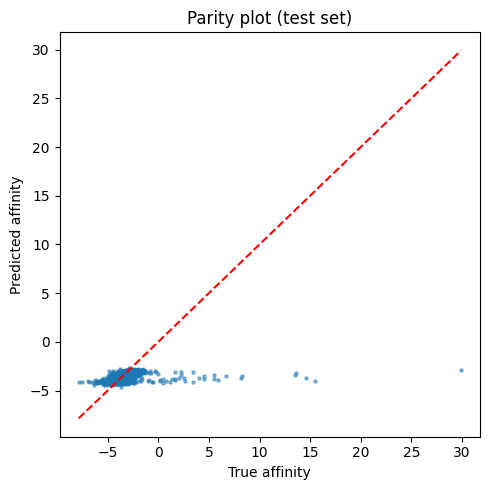

Test MAE: 0.7867


In [11]:
# Parity plot helpers (optional)
import matplotlib.pyplot as plt

def collect_preds(model, loader, device):
    model.eval()
    ys = []
    ys_pred = []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            pred = model(data)
            true = data.y.to(pred.dtype).view(-1)
            ys.append(true.cpu())
            ys_pred.append(pred.cpu())
    if len(ys) == 0:
        return None, None
    ys = torch.cat(ys, dim=0)
    ys_pred = torch.cat(ys_pred, dim=0)
    return ys, ys_pred

ys, ys_pred = collect_preds(model, test_loader, device)
if ys is not None:
    plt.figure(figsize=(5,5))
    plt.scatter(ys, ys_pred, s=5, alpha=0.5)
    min_v = min(ys.min().item(), ys_pred.min().item())
    max_v = max(ys.max().item(), ys_pred.max().item())
    plt.plot([min_v, max_v], [min_v, max_v], 'r--')
    plt.xlabel("True affinity")
    plt.ylabel("Predicted affinity")
    plt.title("Parity plot (test set)")
    plt.tight_layout()
    plt.show()
    mae = torch.mean(torch.abs(ys_pred - ys)).item()
    print("Test MAE:", f"{mae:.4f}")
else:
    print("No test samples to plot")
